# [PBT] 화장품 이커머스 ㅣ 13. 모델 구축 · 가정 검정 · 민감도

## 이 노트북이 하는 일

**⑥ 모델링** — 보고서 Ⅳ 가 여기서 나온다.

> 묻는 것 : **이 모형을 믿고 계수를 읽어도 되는가**

```
12  층화 분할 → 로그 변환 → 더미      (12a~12j)
                    ─────────────────────
                    13  적합 → 가정 검정 → 처방 → 민감도 → 성능      ← 이 노트북
                    ─────────────────────
14  교차검증 · Gap% · 트리 비교 · 최종 해석
```

전처리는 `12` 에서 끝냈다. 그러므로 `fit_pipeline` 에는 **적합만** 맡긴다 —
`encode=False, scale=False, vif=False, outlier=False`.

## 여기서 하지 않는 것

| 안 하는 것 | 어디서 |
|---|---|
| 전처리(인코딩·스케일링·이상치·결측) | `12` 에서 끝났다. 여기서 다시 하면 두 벌이 갈린다 |
| 5-Fold 교차검증 · Gap% 판정 | `14` — 분류의 Gap% 기준은 「교재 미기재」라 별도 판단이 필요하다 |
| 트리 계열 비교 · `compare_models` | `14` |
| **βstd 순위·오즈비 문장 해석** | `14` — 여기서는 **표만 산출**하고 읽지 않는다 |
| 후진소거법(`backward=True`) | **쓰지 않는다.** X 6종은 계획서가 근거를 댄 변수다 (`11` 판정 규율) |

---

## 진입 전 확정된 것 — 결과를 보기 전에 정해져 있다

`claude/결정기록_9-1.md` 에 근거 원본이 있다.

### 결정 21번 → **24번으로 확장됨** (2026-09-01, `13` 실행 전)

`21` 번은 `cart_product_view_cnt` **하나만** 대상으로 대응 규칙을 정했다.
그러나 Box-Tidwell 을 돌려 보니 위배된 것은 **`prior_view_cnt`** 였고,
`cart_product_view_cnt` 는 선형성을 유지했다. **대응 규칙이 없는 변수에서 위배가 났다.**

> ⚠️ **이 사실을 숨기지 않는다.** 규칙을 결과 뒤에 만든 것이 되지 않도록,
> 아래 두 가지가 **결과를 보기 전에 기록되어 있었다는 점**을 근거로 삼는다.
>
> - 브리핑 §9 한계 문장(결정 13번) — *"`prior_view_cnt` 는 `log1p` 후에도 왜도가 1.042 …
>   **로짓 선형성은 Box-Tidwell 로 별도 확인한다**"* → 이 변수가 검정 대상이라는 인지는 사전에 있었다.
> - `교재정리_LAB-10.md` §11-1 — **교재 경로(제곱항 우선 → 재검정)** 와 기존 결정 유지 경로를
>   **두 갈래로 병기**해 두었다. 선택지 자체가 사전에 문서화되어 있었다.

**결정 24번 — 확정 내용**

| 항목 | 내용 |
|---|---|
| 처방 | **교재 정석**(LAB-10 05) — `my_logit.fix_linear` 로 **중심화 + 제곱항**, 그 뒤 재검정 |
| 로그 경로 | `allow_shifted_log=False` — 평행이동량이 자의적이라 계수 해석이 무너진다 (helpers 기본값) |
| test·모형 B | **같은 `recipe_` 를 `apply_recipe` 로 재현**한다. 학습 때의 중심화 평균을 그대로 쓴다 |
| **결정 12번 판정** | **제곱항 처방을 받은 핵심 X 는 1차항 `_c` 의 부호·유의성**으로 판정한다 ← **모형 B 적합 전에 확정** |
| 순차 처방 | `fix_linear` 은 **라운드마다 재검정**한다. 한 변수를 고치면 **처음엔 유지였던 변수가 위배로 바뀔 수 있다.** 그 경우에도 위 규칙(제곱항 → 재검정)을 그대로 적용한다 |
| 미해소 시 | `fix_linear` 이 `unresolved_` 로 돌려주면 **구간화하지 않고 한계로 기록**한다 |
| 성능 지표 | **이 판정에 쓰지 않는다.** AIC 는 `fix_linear` 내부 채택 기준이므로 예외 |

### 결정 12번 — 민감도 판정 (8/31 확정, 변경 금지)

> 같은 층화 분할 · 같은 전처리로 두 모형을 적합한다. **X 목록 한 줄만 다르다.**
> **핵심 X 3개** — `prior_view_cnt`(→ `_c`) · `cart_product_view_cnt` · `price` — 의
> **계수 부호와 유의성 판정(α = 0.05)이 두 모형에서 모두 같으면** `category_grp` 제외를 확정한다.
> 하나라도 다르면 포함 버전을 채택하고 사유를 기록한다.
> **AUC 등 성능 지표는 이 판정에 쓰지 않는다.** 부호·유의성은 같으나 계수가 30% 이상 변하면
> 판정은 통과로 하되 기록한다.

### 임계값 — **여기서 확정하고 결과를 보고 바꾸지 않는다**

| 항목 | 규칙 | 사유 |
|---|---|---|
| **주 지표** | **ROC-AUC** — 임계값과 무관하다 | 결정 6번 (8/29 확정) |
| 임계값의 역할 | 보조 지표(정밀도·재현율·F1) 보고용 | 교재 LAB-10 04 |
| 후보 범위 | `0.10 ~ 0.60` 을 `0.01` 간격 + 교재 예제값 `0.3~0.7` 을 `0.1` 간격으로 **함께** 싣는다 | 「교재 미기재」 — 교재는 예제 범위만 보였고 규칙을 선언하지 않았다 |
| 선정 규칙 | **train 에서 F1 이 최대인 지점** | 정밀도·재현율 어느 한쪽을 택할 업무 목적이 명시되지 않았다 |
| **선정은 train 에서만** | test 로 임계값을 고르면 **그 순간 test 가 오염된다** | 🔴 |

---

## ⚠️ helpers 주의 — 이 노트북에서 실제로 걸리는 것 4건

`claude/교재정리_LAB-10.md` §9 의 대조 결과 중 여기에 해당하는 것만 옮긴다.

| # | 함수 | 무슨 일이 일어나는가 | 우리가 하는 일 |
|---|---|---|---|
| 1 | `report_performance` · `report_threshold` | `fit.model.endog` 와 `fit.predict()` 를 쓴다 → **train 전용이다.** test 를 넣을 자리가 없다 | **test 지표는 `sklearn.metrics` 로 직접 계산**한다 (`#06-2`) |
| 2 | `report_performance` 의 AUC 등급 | `auc < 0.6` 을 전부 *"모형이 아무것도 학습하지 못함"* 으로 라벨한다. 교재 표는 **0.5** 를 그 라벨로 두고 0.6~0.7 을 "낮음" 으로 둔다 — **0.5~0.6 구간은 교재에 정의가 없다** | **라벨을 인용하지 않고 값으로 보고**한다 |
| 3 | `test_linear` | `display` 가 주석 처리되어 있어 **표를 반환만 하고 출력하지 않는다** | 반환값을 직접 표시한다 |
| 4 | `fix_linear` 의 로그 경로 | `aic_better = bool(log_fit < fit.aic)` — **적합 객체와 실수를 비교**해 `TypeError` 가 나고 `except` 에 걸린다. 결과적으로 **로그 처방은 어떤 경우에도 채택되지 않는다** | 우리는 `allow_shifted_log=False` 로 로그 경로를 애초에 막았으므로 **판정에 영향이 없다.** 다만 사실을 기록한다 |

> 4번은 우리 결론과 **우연히 같은 방향**이라 문제가 되지 않지만, "제곱항이 채택된 것은
> 로그가 기각돼서다" 라고 쓰면 사실이 아니게 된다. **로그 경로는 애초에 시도되지 않았다.**

## 👥 역할

| 셀 | 누가 |
|---|---|
| `#01`·`#02`·`#04`·`#06`·`#07`·`#09` | **만드는 사람** |
| `#03` 가정 검정 · `#05` 민감도 판정 · `#08` 검수 | **검수하는 사람** — 판정문을 읽고 서명한다 |

## 📐 수치 표기 규칙 (설계 §4-5)

> 판정문의 모든 수치에 **어느 셀에서 나오는지**를 `#03-1` 형태로 적는다.
> 앞 노트북의 파일에서 온 것은 `12g` 처럼 파일을 밝힌다. **둘 다 아닌 수치는 쓰지 않는다.**

---

## #01. 준비

In [1]:
import os, sys, warnings

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
os.chdir(BASE)
sys.path.insert(0, BASE)

from numpy import arange
from pandas import read_csv, read_parquet, DataFrame, Series, set_option, concat
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from IPython.display import display, Markdown

from helpers import my_logit, my_stats, RANDOM_STATE

set_option("display.max_columns", 60)
set_option("display.max_colwidth", 90)
warnings.filterwarnings("ignore")     # statsmodels 의 수렴 관련 경고만 억제한다

OUT  = BASE + r"\output"

Y      = "purchase_7d"
ALPHA  = 0.05
VIF_MAX = 10.0

# 결정 12번 — 민감도 판정 대상. 결정 24번 보칙에 따라 prior_view_cnt 는 1차항으로 본다
CORE3  = ["price", "prior_view_cnt", "cart_product_view_cnt"]

# 임계값 후보 — 위에서 확정한 규칙 그대로
THR_FINE = [round(t, 2) for t in arange(0.10, 0.61, 0.01)]
THR_BOOK = [0.3, 0.4, 0.5, 0.6, 0.7]        # 교재 예제 범위 (LAB-10 04)

print("데이터 폴더 :", OUT)
print(f"RANDOM_STATE : {RANDOM_STATE}   ·   α = {ALPHA}")
print(f"임계값 후보 : {THR_FINE[0]} ~ {THR_FINE[-1]} ({len(THR_FINE)}개) + 교재 예제 {THR_BOOK}")

데이터 폴더 : .\output
RANDOM_STATE : 3217   ·   α = 0.05
임계값 후보 : 0.1 ~ 0.6 (51개) + 교재 예제 [0.3, 0.4, 0.5, 0.6, 0.7]


### 1-1. `12` 산출물 수령 — 하나라도 어긋나면 멈춘다

In [2]:
A_tr = read_parquet(OUT + r"\12a_X_train.parquet")
A_te = read_parquet(OUT + r"\12b_X_test.parquet")
B_tr = read_parquet(OUT + r"\12h_XB_train.parquet")
B_te = read_parquet(OUT + r"\12i_XB_test.parquet")
y_tr = read_csv(OUT + r"\12c_y_train.csv", encoding="utf-8-sig", index_col="user_id")[Y]
y_te = read_csv(OUT + r"\12d_y_test.csv",  encoding="utf-8-sig", index_col="user_id")[Y]
REFTAB = read_csv(OUT + r"\12j_기준범주.csv", encoding="utf-8-sig", index_col="변수")

# Logit 은 수치 행렬 연산이므로 더미의 int 와 연속형의 float 를 섞지 않는다
A_tr = A_tr.astype(float); A_te = A_te.astype(float)
B_tr = B_tr.astype(float); B_te = B_te.astype(float)

수령 = [("12a X_train", f"{A_tr.shape[0]:,} × {A_tr.shape[1]}", "86,766 × 26"),
        ("12b X_test",  f"{A_te.shape[0]:,} × {A_te.shape[1]}", "21,692 × 26"),
        ("12h XB_train", f"{B_tr.shape[0]:,} × {B_tr.shape[1]}", "86,766 × 84"),
        ("12i XB_test",  f"{B_te.shape[0]:,} × {B_te.shape[1]}", "21,692 × 84"),
        ("12c y_train",  f"{len(y_tr):,}행 양성 {int(y_tr.sum()):,}", "86,766행 양성 17,789"),
        ("12d y_test",   f"{len(y_te):,}행 양성 {int(y_te.sum()):,}", "21,692행 양성 4,447"),
        ("12j 기준범주",  f"{REFTAB.shape[0]}행", "4행")]
R = DataFrame(수령, columns=["파일", "이번 실행", "12번 값"])
R["일치"] = R["이번 실행"] == R["12번 값"]

assert R["일치"].all(), "❌ 12번 산출물과 어긋난다. 여기서 멈춘다."
print("기준 범주 (12j) —", " · ".join(f"{i}: {r['우리가 지정한 기준']}" for i, r in REFTAB.iterrows()))
R

기준 범주 (12j) — brand_grp: runail · cart_timeband: 심야 · cart_weekday: 월 · category_grp: 기타


,파일,이번 실행,12번 값,일치
0,12a X_train,"86,766 × 26","86,766 × 26",True
1,12b X_test,"21,692 × 26","21,692 × 26",True
2,12h XB_train,"86,766 × 84","86,766 × 84",True
3,12i XB_test,"21,692 × 84","21,692 × 84",True
4,12c y_train,"86,766행 양성 17,789","86,766행 양성 17,789",True
5,12d y_test,"21,692행 양성 4,447","21,692행 양성 4,447",True
6,12j 기준범주,4행,4행,True


### 1-2. 누수와 정렬 재확인 — `12` 에서 통과했어도 여기서 다시 본다

파일을 거쳐 왔으므로 **열 순서가 저장·로드 과정에서 바뀌었을 수 있다.**
`predict` 는 `add_constant` 만 붙이고 넘기므로 열 순서가 어긋나면 **조용히 틀린 값**이 나온다.

In [3]:
FORBIDDEN = ["lag_hours", "purchase_7d", "user_id", "t0", "product_id",
             "brand", "category_id", "has_prior_view", "prior_uniq_product_cnt"]

공통 = [c for c in A_tr.columns if c in B_tr.columns]
점검 = [("금지 변수 부재 (A)",        not [c for c in FORBIDDEN if c in A_tr.columns]),
        ("금지 변수 부재 (B)",        not [c for c in FORBIDDEN if c in B_tr.columns]),
        ("A train/test 열 순서 동일", list(A_tr.columns) == list(A_te.columns)),
        ("B train/test 열 순서 동일", list(B_tr.columns) == list(B_te.columns)),
        ("A 26열이 B 안에 그대로",     len(공통) == A_tr.shape[1]),
        ("A·B 공통열 값 동일 (train)", A_tr[공통].equals(B_tr[공통])),
        ("A·B 분할 인덱스 동일",       list(A_tr.index) == list(B_tr.index)),
        ("X·y 인덱스 순서 동일 (train)", list(A_tr.index) == list(y_tr.index)),
        ("X·y 인덱스 순서 동일 (test)",  list(A_te.index) == list(y_te.index)),
        ("category_grp 이 A 에 없음",  not [c for c in A_tr.columns if c.startswith("category_grp")]),
        ("결측 0",                    int(A_tr.isna().sum().sum() + A_te.isna().sum().sum()) == 0)]
P = DataFrame(점검, columns=["항목", "통과"])

assert P["통과"].all(), f"❌ {list(P[~P['통과']]['항목'])}"
print(f"{len(P)} / {len(P)} 통과 ✅")
P

11 / 11 통과 ✅


,항목,통과
0,금지 변수 부재 (A),True
1,금지 변수 부재 (B),True
2,A train/test 열 순서 동일,True
3,B train/test 열 순서 동일,True
4,A 26열이 B 안에 그대로,True
5,A·B 공통열 값 동일 (train),True
6,A·B 분할 인덱스 동일,True
7,X·y 인덱스 순서 동일 (train),True
8,X·y 인덱스 순서 동일 (test),True
9,category_grp 이 A 에 없음,True


---

## #02. 기준선 모형 A0 — 적합만 맡긴다

`fit_pipeline` 의 플래그를 전부 끄면 내부적으로 `fit_model` 과 같아진다.
그래도 `fit_pipeline` 을 쓰는 이유는 **`data_`·`recipe_`·`name_` 이 결과 객체에 붙어**
뒤 셀들이 같은 데이터를 다시 조립하지 않아도 되기 때문이다.

> `backward=False` — 후진소거법을 쓰지 않는다. `11` 의 판정 규율이 *"계획서가 근거를 댄 변수는
> 효과가 작아도 자르지 않는다"* 이므로, 유의성으로 변수를 떨어뜨리면 그 규율을 스스로 뒤집는 것이 된다.

In [4]:
TRAIN_A = concat([A_tr, y_tr], axis=1)
TEST_A  = concat([A_te, y_te], axis=1)

A0 = my_logit.fit_pipeline(TRAIN_A, y=Y,
                           outlier=False, encode=False, vif=False, scale=False,
                           backward=False, alpha=ALPHA, name="A0 기준선(26열)")

print(f"수렴 : {A0.mle_retvals['converged']}")
print(f"독립변수 {len(A0.params) - 1}개 + 상수항   ·   관측치 {int(A0.nobs):,}")
print(f"모형 유의성 (우도비) : LLR χ² = {A0.llr:.1f},  p = {A0.llr_pvalue:.3e}"
      f"  → {'유의함' if A0.llr_pvalue < ALPHA else '유의하지 않음'}")
print(f"Pseudo R² (McFadden) : {A0.prsquared:.4f}")
print(f"AIC : {A0.aic:.2f}   ·   Log-Likelihood : {A0.llf:.2f}")


수렴 : True
독립변수 26개 + 상수항   ·   관측치 86,766
모형 유의성 (우도비) : LLR χ² = 1413.3,  p = 4.217e-282  → 유의함
Pseudo R² (McFadden) : 0.0161
AIC : 86671.24   ·   Log-Likelihood : -43308.62


### 2-1. 모형 적합도 보고 문장 (`report_fitness`)

In [5]:
display(Markdown(my_logit.report_fitness(A0)))

**Note. n = 86766. LL = -43308.62, LL-Null = -44015.266, LLR x²(26) = 1413.292, p < 0.001, Pseudo R² = 0.016**

purchase_7d를 종속변수로, price, prior_view_cnt, cart_product_view_cnt, brand_grp_bpw.style, brand_grp_cnd, brand_grp_concept, brand_grp_estel, brand_grp_grattol, brand_grp_ingarden, brand_grp_irisk, brand_grp_italwax, brand_grp_jessnail, brand_grp_kapous, brand_grp_masura, brand_grp_uno, brand_grp_기타, brand_grp_미상, cart_timeband_오전, cart_timeband_오후, cart_timeband_저녁, cart_weekday_화, cart_weekday_수, cart_weekday_목, cart_weekday_금, cart_weekday_토, cart_weekday_일(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x²(26) = 1413.292, p < 0.001, Pseudo R² = 0.016.

즉, 모형의 유사결정계수는 0.016로 다소 낮은 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2 ~ 0.4** 구간이면 매우 우수한 적합으로 본다.

---

## #03. 가정 검정 (LAB-10 05) 〈검수하는 사람이 판정문을 읽는다〉

로지스틱의 가정은 **로짓 선형성 · 다중공선성 · 독립성** 셋이다.
정규성과 등분산성은 로지스틱의 가정이 **아니다** — 종속변수가 0/1이라 오차항이 이항분포를 따른다.

### 3-1. 로짓 선형성 — Box-Tidwell

**판정 규칙을 결과보다 먼저 적는다.**

> 독립변수 `x` 에 `x × ln(x)` 항을 추가해 그 항이 유의한지 본다.
> **p ≥ 0.05 → 선형성 위배 근거 없음 / p < 0.05 → 위배(처방 필요).**
> 이분형(더미)은 두 점을 잇는 선이 언제나 직선이므로 검정 대상에서 제외한다
> (`test_linear` 이 `nunique() > 2` 로 자동 선별한다 → 연속 3종만).

⚠️ `test_linear` 은 `display` 가 주석 처리되어 **반환만 하고 출력하지 않는다.** 직접 표시한다.
⚠️ 반환표의 `p-value` 는 helpers 가 **소수 4자리로 반올림**한 값이다. `0.0` 은 `p < 0.00005` 를 뜻한다.

In [6]:
XN_A0 = [c for c in A0.model.exog_names if c != "const"]

BT0 = my_logit.test_linear(A0, data=TRAIN_A, yname=Y, xnames=XN_A0, alpha=ALPHA)
BT0 = BT0.sort_values("p-value")

위배 = list(BT0[~BT0["linearity"]].index)
print(f"검정 대상 {len(BT0)}개 (연속형만) · 위배 {len(위배)}개 → {위배 if 위배 else '없음'}")
print(f"「위치이동」 True 는 ln 의 정의역을 맞추려 평행이동했다는 뜻이다 —")
print(f"  log 변환 후 값이 음수를 포함하기 때문이며(price 최소 log(0.05)), 검정 자체에는 영향이 없다.")
BT0

검정 대상 3개 (연속형만) · 위배 1개 → ['prior_view_cnt']
「위치이동」 True 는 ln 의 정의역을 맞추려 평행이동했다는 뜻이다 —
  log 변환 후 값이 음수를 포함하기 때문이며(price 최소 log(0.05)), 검정 자체에는 영향이 없다.


,z,p-value,linearity,위치이동,result
독립변수,,,,,
prior_view_cnt,5.2909,0.0000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
cart_product_view_cnt,-1.3546,0.1755,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음
price,-0.3805,0.7036,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음


### 3-2. 판정 — 사전 규칙에 대입한다

`#03-1` 의 결과를 **결정 21번·24번의 문장에 그대로 대입**한다. 여기서 규칙을 만들지 않는다.

In [7]:
규칙 = []
for x in BT0.index:
    p = float(BT0.loc[x, "p-value"])
    if x == "cart_product_view_cnt":
        근거 = "결정 21번 — 위배 시 제곱항 먼저, 그래도 안 되면 구간화(경계 0/1/2/3/4+)"
    else:
        근거 = "결정 24번 — 위배 시 fix_linear 의 중심화+제곱항, 로그 경로는 막음"
    규칙.append({"변수": x, "p": p,
                 "판정": "위배 → 처방" if p < ALPHA else "유지 → 처방하지 않음",
                 "적용할 사전 규칙": 근거})
JUDGE = DataFrame(규칙).set_index("변수")

print("사전 규칙 대입 결과")
for x, r in JUDGE.iterrows():
    print(f"  {x:24s} p={r['p']:<10.4g} {r['판정']}")
print()
if "cart_product_view_cnt" in 위배:
    print("→ 결정 21번이 대비한 상황이다. 제곱항 → (실패 시) 구간화 순서로 처방한다.")
else:
    print("→ 이 시점에서는 결정 21번이 대비한 상황이 아니다. 위배는 prior_view_cnt 하나뿐이다.")
print("→ 위배는 결정 24번대로 fix_linear 의 중심화+제곱항으로 처방한다 (#04).")
print()
print("⚠️ 이 표는 '지금 시점'의 판정이다. fix_linear 은 라운드마다 재검정하므로,")
print("   한 변수를 고치면 여기서 '유지'였던 변수가 위배로 바뀔 수 있다.")
print("   그 경우에도 사전 규칙(제곱항 → 재검정, 실패 시에만 구간화)을 그대로 적용한다.")
JUDGE

사전 규칙 대입 결과
  prior_view_cnt           p=0          위배 → 처방
  cart_product_view_cnt    p=0.1755     유지 → 처방하지 않음
  price                    p=0.7036     유지 → 처방하지 않음

→ 이 시점에서는 결정 21번이 대비한 상황이 아니다. 위배는 prior_view_cnt 하나뿐이다.
→ 위배는 결정 24번대로 fix_linear 의 중심화+제곱항으로 처방한다 (#04).

⚠️ 이 표는 '지금 시점'의 판정이다. fix_linear 은 라운드마다 재검정하므로,
   한 변수를 고치면 여기서 '유지'였던 변수가 위배로 바뀔 수 있다.
   그 경우에도 사전 규칙(제곱항 → 재검정, 실패 시에만 구간화)을 그대로 적용한다.


,p,판정,적용할 사전 규칙
변수,,,
prior_view_cnt,0.0000,위배 → 처방,"결정 24번 — 위배 시 fix_linear 의 중심화+제곱항, 로그 경로는 막음"
cart_product_view_cnt,0.1755,유지 → 처방하지 않음,"결정 21번 — 위배 시 제곱항 먼저, 그래도 안 되면 구간화(경계 0/1/2/3/4+)"
price,0.7036,유지 → 처방하지 않음,"결정 24번 — 위배 시 fix_linear 의 중심화+제곱항, 로그 경로는 막음"


### 3-3. 다중공선성 — `12g` 와 대조한다

같은 설계행렬이므로 값이 같아야 한다. 다르면 파일을 거치며 무언가 바뀐 것이다.

In [8]:
VIF_now = my_stats.compute_vif(A_tr, columns=list(A_tr.columns))
VIF_12g = read_csv(OUT + r"\12g_더미후VIF.csv", encoding="utf-8-sig", index_col=0)

대조 = VIF_now[["VIF"]].join(VIF_12g[["VIF"]], rsuffix="_12g")
대조["차이"] = (대조["VIF"] - 대조["VIF_12g"]).abs()
일치 = bool((대조["차이"] < 1e-9).all())

print(f"12g 와 일치 : {'✅' if 일치 else '❌'}   ·   최대 VIF {VIF_now['VIF'].max():.3f} (임계 {VIF_MAX})")
print(f"임계 초과 : {int((VIF_now['VIF'] > VIF_MAX).sum())}개")
print("※ 자동 제거하지 않는다 (설계 §3-9). 더미는 서로 VIF 가 오르는 것이 정상이다.")
assert 일치, "❌ 12g 와 VIF 가 다르다. 설계행렬이 바뀌었다."
VIF_now.head(6)

12g 와 일치 : ✅   ·   최대 VIF 4.482 (임계 10.0)
임계 초과 : 0개
※ 자동 제거하지 않는다 (설계 §3-9). 더미는 서로 VIF 가 오르는 것이 정상이다.


,VIF
brand_grp_미상,4.481510
brand_grp_기타,3.763870
cart_timeband_오후,3.374646
cart_timeband_저녁,3.305424
cart_timeband_오전,2.817174
cart_weekday_금,1.808128


### 3-4. 독립성 — Durbin-Watson **(해석에 단서를 단다)**

`test_independent` 는 피어슨 잔차에 Durbin-Watson 을 건다. 본래 **시계열 전용 검정**이고,
우리 데이터는 **1행 = 1고객으로 시간 순서가 없다.** 통계량이 정상 범위에 들어와도
그것이 독립성의 증거가 되지는 않는다 — helpers 의 docstring 도 *"최종 판단은 자료 수집 설계로
해야 한다"* 고 적어 두었다.

**우리의 독립성 근거는 설계다** — 고객당 최초 장바구니 1건만 쓰므로 한 사람이 두 번 들어가지 않는다
(`03` `#05`, 동시각 복수 상품 172명 제외).

In [9]:
IND = my_logit.test_independent(A0)
print(f"Durbin-Watson = {float(IND['statistic'].iloc[0]):.4f}  → {IND['result'].iloc[0]}")
print()
print("※ 이 값을 독립성의 근거로 쓰지 않는다. 행에 시간 순서가 없어 자기상관 개념이 성립하지 않는다.")
print("  근거는 설계다 — 1행 = 1고객, 고객당 최초 장바구니 1건 (03 #05).")
print(f"  1행=1고객 재확인 : 중복 인덱스 {int(A_tr.index.duplicated().sum())}개")
IND

Durbin-Watson = 1.9930  → 독립성 만족

※ 이 값을 독립성의 근거로 쓰지 않는다. 행에 시간 순서가 없어 자기상관 개념이 성립하지 않는다.
  근거는 설계다 — 1행 = 1고객, 고객당 최초 장바구니 1건 (03 #05).
  1행=1고객 재확인 : 중복 인덱스 0개


,statistic,independence,result
Durbin-Watson,1.993,True,독립성 만족


---

## #04. 결정 24번 처방 — 중심화 + 제곱항

`fix_linear` 이 하는 일 : 위배 변수를 `|z|` 큰 순으로 하나씩 잡아
**중심화 후 제곱항**(`x_c`, `x_c2`)을 넣고 → 우도비 검정과 재검정으로 채택 여부를 판단 → 다음 변수.

- `allow_shifted_log=False` — 로그 경로를 막는다. 평행이동량이 자의적이라 계수 해석이 무너진다.
- ⚠️ 애초에 helpers 의 로그 경로는 `bool(log_fit < fit.aic)` 로 **적합 객체와 실수를 비교**해
  `TypeError` 가 나고 `except` 에 걸린다. **어떤 설정에서도 채택되지 않는다.**
  우리 판정에는 영향이 없지만, *"로그가 기각돼서 제곱항이 됐다"* 고 쓰면 사실이 아니다.
- 중심화 평균은 **train 의 값**이고, `recipe_` 에 담겨 test·모형 B 에 그대로 재사용된다.

In [10]:
if 위배:
    A1 = my_logit.fix_linear(TRAIN_A, y=Y, alpha=ALPHA,
                             allow_shifted_log=False, report=True)
    RECIPE = A1.recipe_
    처방됨 = True
else:
    A1, RECIPE, 처방됨 = A0, {}, False
    print("위배가 없어 처방하지 않는다.")

print()
print(f"처방 내역 (recipe_) : {RECIPE}")
print(f"미해소 변수 (unresolved_) : {getattr(A1, 'unresolved_', [])}")
if getattr(A1, "unresolved_", []):
    print("  → 제곱항으로 담기지 않는 형태다. 결정 24번대로 **구간화하지 않고 한계로 기록**한다.")

[라운드 1] 위배 1종 → 'prior_view_cnt' 처방 (z = 5.2909)
    → 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 4.7168e-08, AIC = 86643.41
[라운드 2] 위배 1종 → 'cart_product_view_cnt' 처방 (z = -3.3176)
    → 제곱항 채택 (제곱항 p = 0.0009), 우도비 p = 8.7052e-04, AIC = 86634.33
[라운드 3] 위배 변수 없음 → 루프 종료



,변수,처방,제곱항 p,검증 p,AIC,채택
라운드,,,,,,
1,prior_view_cnt,제곱항,0.0000,0.0000,86643.41,True
2,cart_product_view_cnt,제곱항,0.0009,0.0009,86634.33,True



처방 내역 (recipe_) : {'prior_view_cnt': {'method': 'square', 'center': 0.5747747582111533, 'shift': None}, 'cart_product_view_cnt': {'method': 'square', 'center': 0.2955369759058348, 'shift': None}}
미해소 변수 (unresolved_) : []


### 4-1. 처방 후 재검정 — 위배가 해소되었는가

처방이 목적을 달성했는지 **같은 검정으로 다시 확인**한다. 통과하지 못하면 한계로 기록한다.

In [11]:
A1_tr = A1.data_.drop(columns=[Y])          # 파생변수가 반영된 train 설계행렬
XN_A1 = [c for c in A1.model.exog_names if c != "const"]

BT1 = my_logit.test_linear(A1, data=A1.data_, yname=Y, xnames=XN_A1, alpha=ALPHA)
BT1 = BT1.sort_values("p-value")

남은위배 = list(BT1[~BT1["linearity"]].index)
처방받은 = list(RECIPE.keys())
뒤늦게 = [c for c in 처방받은 if c not in 위배]

print(f"#03-1 시점 위배 : {위배}")
print(f"실제 처방받은 변수 : {처방받은}")
if 뒤늦게:
    print(f"  ↳ {뒤늦게} 는 #03-1 에서는 '유지'였으나, 앞 변수를 고친 뒤 재검정에서 위배로 바뀌었다.")
    print(f"     사전 규칙대로 제곱항을 먼저 적용했고, 통과했으므로 **구간화하지 않는다**.")
    if "cart_product_view_cnt" in 뒤늦게:
        print(f"     → 『11』이 남긴 「구간화 검토」 지시는 여기서 닫힌다 — 제곱항으로 해소됐다 (결정 21번).")
print(f"처방 후 위배 : {남은위배 if 남은위배 else '없음 ✅'}")
print(f"열 : {A_tr.shape[1]}개 → {A1_tr.shape[1]}개"
      f"   (원본 {len(처방받은)}개가 각각 _c · _c2 로 바뀌어 +{len(처방받은)}열)")
print(f"AIC : {A0.aic:.2f} → {A1.aic:.2f}")
print()
print("※ AIC 는 fix_linear 내부의 채택 기준이라 여기 적는다. 모형 선택의 근거로는 쓰지 않는다.")
BT1

#03-1 시점 위배 : ['prior_view_cnt']
실제 처방받은 변수 : ['prior_view_cnt', 'cart_product_view_cnt']
  ↳ ['cart_product_view_cnt'] 는 #03-1 에서는 '유지'였으나, 앞 변수를 고친 뒤 재검정에서 위배로 바뀌었다.
     사전 규칙대로 제곱항을 먼저 적용했고, 통과했으므로 **구간화하지 않는다**.
     → 『11』이 남긴 「구간화 검토」 지시는 여기서 닫힌다 — 제곱항으로 해소됐다 (결정 21번).
처방 후 위배 : 없음 ✅
열 : 26개 → 28개   (원본 2개가 각각 _c · _c2 로 바뀌어 +2열)
AIC : 86671.24 → 86634.33

※ AIC 는 fix_linear 내부의 채택 기준이라 여기 적는다. 모형 선택의 근거로는 쓰지 않는다.


,z,p-value,linearity,위치이동,result
독립변수,,,,,
price,-0.2479,0.8042,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음
cart_product_view_cnt_c2,0.1510,0.8800,True,False,귀무가설 채택 → 로짓 선형성 위배 근거 없음
cart_product_view_cnt_c,-0.1327,0.8944,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음
prior_view_cnt_c2,0.0860,0.9315,True,False,귀무가설 채택 → 로짓 선형성 위배 근거 없음
prior_view_cnt_c,-0.0724,0.9423,True,True,귀무가설 채택 → 로짓 선형성 위배 근거 없음


### 4-2. test 에 같은 처방을 재현한다 — `apply_recipe`

**중심화 평균은 반드시 train 의 값을 쓴다.** test 에서 다시 계산하면 그 순간 🔴 누수다.
`apply_recipe` 는 `recipe_` 에 담긴 학습 시점의 `center` 를 그대로 쓴다.

`apply_recipe` 는 원본 열을 **제거하고** 파생 열을 **뒤에 붙이므로 열 순서가 바뀐다.**
적합된 모형의 순서로 다시 정렬해야 `predict` 가 올바른 값을 낸다.

In [12]:
A1_te = my_logit.apply_recipe(A_te, RECIPE) if 처방됨 else A_te.copy()

# 적합된 모형의 열 순서로 강제 정렬 — predict 는 순서가 틀려도 오류를 내지 않는다
A1_te = A1_te.reindex(columns=XN_A1)
A1_tr = A1_tr.reindex(columns=XN_A1)

assert list(A1_te.columns) == XN_A1, "❌ test 열이 모형 열과 다르다"
assert int(A1_te.isna().sum().sum()) == 0, "❌ reindex 로 없는 열이 생겼다 (NaN)"

# 중심화 평균이 train 값 그대로 쓰였는지 직접 확인한다
if 처방됨:
    for col, rule in RECIPE.items():
        c = rule["center"]
        재현 = float((A_te[col] - c).head(1).iloc[0])
        실제 = float(A1_te[col + "_c"].head(1).iloc[0])
        print(f"  {col}: center={c:.6f} (train 평균 {A_tr[col].mean():.6f}) · "
              f"test 첫 행 재현 {재현:.6f} == {실제:.6f} : {abs(재현 - 실제) < 1e-12}")

print(f"\ntest 설계행렬 : {A1_te.shape[0]:,}행 × {A1_te.shape[1]}열   (train 과 열·순서 동일 ✅)")
A1_te.head(3)

  prior_view_cnt: center=0.574775 (train 평균 0.574775) · test 첫 행 재현 -0.574775 == -0.574775 : True
  cart_product_view_cnt: center=0.295537 (train 평균 0.295537) · test 첫 행 재현 -0.295537 == -0.295537 : True

test 설계행렬 : 21,692행 × 28열   (train 과 열·순서 동일 ✅)


,price,brand_grp_bpw.style,brand_grp_cnd,brand_grp_concept,brand_grp_estel,brand_grp_grattol,brand_grp_ingarden,brand_grp_irisk,brand_grp_italwax,brand_grp_jessnail,brand_grp_kapous,brand_grp_masura,brand_grp_uno,brand_grp_기타,brand_grp_미상,cart_timeband_오전,cart_timeband_오후,cart_timeband_저녁,cart_weekday_화,cart_weekday_수,cart_weekday_목,cart_weekday_금,cart_weekday_토,cart_weekday_일,prior_view_cnt_c,prior_view_cnt_c2,cart_product_view_cnt_c,cart_product_view_cnt_c2
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
481564147,2.754297,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.574775,0.330366,-0.295537,0.087342
547247856,0.548121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.727810,2.985329,-0.295537,0.087342
462461123,3.790759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.118372,0.014012,0.397610,0.158094


---

## #05. 결정 12번 민감도 — 모형 B 〈검수하는 사람이 판정한다〉

`category_grp` 제외가 결론을 바꾸지 않는지 확인한다. **X 목록 한 줄만 다르다.**

| 모형 | 열 | `category_grp` |
|---|---|---|
| A1 | 26 (+ 처방분) | 제외 |
| B1 | 84 (+ 처방분) | 포함 (59종 → 58 더미) |

**판정 대상은 핵심 X 3개의 부호와 유의성뿐이다.**
**제곱항 처방을 받은 변수는 결정 24번 보칙대로 1차항 `_c` 로 본다** — 이 보칙은 **B 를 적합하기 전에** 정했다.

> 🔴 **AUC 등 성능 지표는 이 판정에 쓰지 않는다.** 아래 표에 성능 컬럼을 두지 않는 것으로 강제한다.
> `my_logit.compare_models` 는 AUC 로 순위를 매기므로 **이 판정에 쓰면 안 된다.**

In [13]:
B1_tr = my_logit.apply_recipe(B_tr, RECIPE) if 처방됨 else B_tr.copy()
B1_te = my_logit.apply_recipe(B_te, RECIPE) if 처방됨 else B_te.copy()

B1 = my_logit.fit_pipeline(concat([B1_tr, y_tr], axis=1), y=Y,
                           outlier=False, encode=False, vif=False, scale=False,
                           backward=False, alpha=ALPHA, name="B1 대조(84열+처방)")

# 같은 전처리인지 코드로 확인 — A 의 열이 B 안에 같은 값으로 있어야 한다
공통1 = [c for c in A1_tr.columns if c in B1_tr.columns]
assert len(공통1) == A1_tr.shape[1] and A1_tr[공통1].equals(B1_tr[공통1]), "❌ A·B 전처리가 갈렸다"
assert list(A1_tr.index) == list(B1_tr.index), "❌ A·B 분할이 다르다"

print(f"A1 {A1_tr.shape[1]}열   ·   B1 {B1_tr.shape[1]}열   (차이 {B1_tr.shape[1] - A1_tr.shape[1]}열)")
print(f"A1 의 열이 B1 안에 같은 값으로 존재 ✅   ·   분할 인덱스 동일 ✅")
print(f"수렴 : A1 {A1.mle_retvals['converged']} · B1 {B1.mle_retvals['converged']}")
print(f"EPV : A1 {round(int(y_tr.sum()) / A1_tr.shape[1])} · B1 {round(int(y_tr.sum()) / B1_tr.shape[1])}  (통상 기준 10)")


A1 28열   ·   B1 86열   (차이 58열)
A1 의 열이 B1 안에 같은 값으로 존재 ✅   ·   분할 인덱스 동일 ✅
수렴 : A1 True · B1 True
EPV : A1 635 · B1 207  (통상 기준 10)


### 5-1. 핵심 X 3개 대조 — 부호와 유의성만 본다

In [14]:
# 결정 24번 보칙 — prior_view_cnt 는 1차항(_c)으로 판정한다
def 판정변수(x):
    return x + "_c" if (처방됨 and x in RECIPE and RECIPE[x]["method"] == "square") else x

rows = []
for x in CORE3:
    v = 판정변수(x)
    bA, pA = float(A1.params[v]), float(A1.pvalues[v])
    bB, pB = float(B1.params[v]), float(B1.pvalues[v])
    rows.append({"핵심 X": x, "판정에 쓴 항": v,
                 "A1 B": round(bA, 4), "A1 부호": "+" if bA > 0 else "-",
                 "A1 유의": pA < ALPHA, "A1 p": pA,
                 "B1 B": round(bB, 4), "B1 부호": "+" if bB > 0 else "-",
                 "B1 유의": pB < ALPHA, "B1 p": pB,
                 "부호 동일": (bA > 0) == (bB > 0),
                 "유의성 동일": (pA < ALPHA) == (pB < ALPHA),
                 "계수 변화율(%)": round(abs(bB - bA) / abs(bA) * 100, 1)})

SENS = DataFrame(rows).set_index("핵심 X")
통과 = bool(SENS["부호 동일"].all() and SENS["유의성 동일"].all())
큰변화 = list(SENS[SENS["계수 변화율(%)"] >= 30].index)

for x, r in SENS.iterrows():
    print(f"  {x:24s} A1 {r['A1 부호']}{abs(r['A1 B']):.4f} (p={r['A1 p']:.3g})"
          f"   B1 {r['B1 부호']}{abs(r['B1 B']):.4f} (p={r['B1 p']:.3g})"
          f"   변화 {r['계수 변화율(%)']:.1f}%")
SENS[["판정에 쓴 항", "A1 부호", "A1 유의", "B1 부호", "B1 유의", "부호 동일", "유의성 동일", "계수 변화율(%)"]]

  price                    A1 +0.1347 (p=9.63e-61)   B1 +0.1902 (p=4.7e-68)   변화 41.1%
  prior_view_cnt           A1 -0.1725 (p=7.78e-12)   B1 -0.1727 (p=8.85e-12)   변화 0.1%
  cart_product_view_cnt    A1 +0.7203 (p=6.84e-73)   B1 +0.7196 (p=6.52e-72)   변화 0.1%


,판정에 쓴 항,A1 부호,A1 유의,B1 부호,B1 유의,부호 동일,유의성 동일,계수 변화율(%)
핵심 X,,,,,,,,
price,price,+,True,+,True,True,True,41.1
prior_view_cnt,prior_view_cnt_c,-,True,-,True,True,True,0.1
cart_product_view_cnt,cart_product_view_cnt_c,+,True,+,True,True,True,0.1


### 5-2. 판정문 — 사전 규칙 그대로

In [15]:
print("결정 12번 판정 규칙 (8/31 확정)")
print("  핵심 X 3개의 계수 부호와 유의성(α=0.05)이 두 모형에서 모두 같으면 category_grp 제외를 확정한다.")
print("  하나라도 다르면 포함 버전을 채택하고 사유를 기록한다.")
print("  부호·유의성은 같으나 계수가 30% 이상 변한 변수가 있으면 판정은 통과로 하되 기록한다.")
print()
print(f"결과 → 부호 동일 {int(SENS['부호 동일'].sum())}/3 · 유의성 동일 {int(SENS['유의성 동일'].sum())}/3")
print()
if 통과:
    print("✅ 판정 : 통과. category_grp 제외를 확정한다.")
    print("   가장 강하게 통제한 버전(500건 기준, 59종)에서도 핵심 X 3개의 부호와 유의성이 같으므로,")
    print("   그보다 약한 어떤 통제 수준에서도 결론이 바뀌지 않는다.")
else:
    print("❌ 판정 : 불통과. 포함 버전(모형 B)을 채택하고 사유를 기록한다.")
    print(f"   어긋난 변수 : {list(SENS[~(SENS['부호 동일'] & SENS['유의성 동일'])].index)}")
if 큰변화:
    print(f"\n⚠️ 계수가 30% 이상 변한 변수 : {큰변화} — 판정은 통과이나 보고서 Ⅵ-3 에 기록한다.")
else:
    print("\n계수 30% 이상 변동 : 없음")
print("\n※ AUC 를 이 판정에 쓰지 않았다. 위 표에 성능 컬럼이 없는 것이 그 증거다.")

결정 12번 판정 규칙 (8/31 확정)
  핵심 X 3개의 계수 부호와 유의성(α=0.05)이 두 모형에서 모두 같으면 category_grp 제외를 확정한다.
  하나라도 다르면 포함 버전을 채택하고 사유를 기록한다.
  부호·유의성은 같으나 계수가 30% 이상 변한 변수가 있으면 판정은 통과로 하되 기록한다.

결과 → 부호 동일 3/3 · 유의성 동일 3/3

✅ 판정 : 통과. category_grp 제외를 확정한다.
   가장 강하게 통제한 버전(500건 기준, 59종)에서도 핵심 X 3개의 부호와 유의성이 같으므로,
   그보다 약한 어떤 통제 수준에서도 결론이 바뀌지 않는다.

⚠️ 계수가 30% 이상 변한 변수 : ['price'] — 판정은 통과이나 보고서 Ⅵ-3 에 기록한다.

※ AUC 를 이 판정에 쓰지 않았다. 위 표에 성능 컬럼이 없는 것이 그 증거다.


---

## #06. 성능 평가 — **주 지표는 ROC-AUC** (결정 6번)

> ⚠️ `report_performance` 와 `report_threshold` 는 `fit.model.endog` 와 `fit.predict()` 를 쓴다.
> **train 전용이고 test 를 넣을 자리가 없다.** test 지표는 `sklearn.metrics` 로 직접 계산한다.
> 교재가 지표 개념을 가르쳤고(LAB-10 04) 함수만 없는 것이므로 새로 배울 것은 없다.

### 6-1. train — 교재 함수 (`report_performance`)

⚠️ 이 함수의 AUC 등급 라벨은 `auc < 0.6` 을 전부 *"모형이 아무것도 학습하지 못함"* 으로 찍는다.
**교재 표는 0.5 를 그 라벨로 두고 0.6~0.7 을 "낮음" 으로 둔다 — 0.5~0.6 구간은 교재에 정의가 없다.**
**라벨을 인용하지 말고 값으로 보고한다.**

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),68976,1
실제 1 (Positive),17789,0


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,TPR)","위양성률(Fallout,FPR)","특이성(Specificity,TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
Performance,0.794966,0.0,0.0,0.000014,0.999986,0.0,0.591513,모형이 아무것도 학습하지 못함,0.0


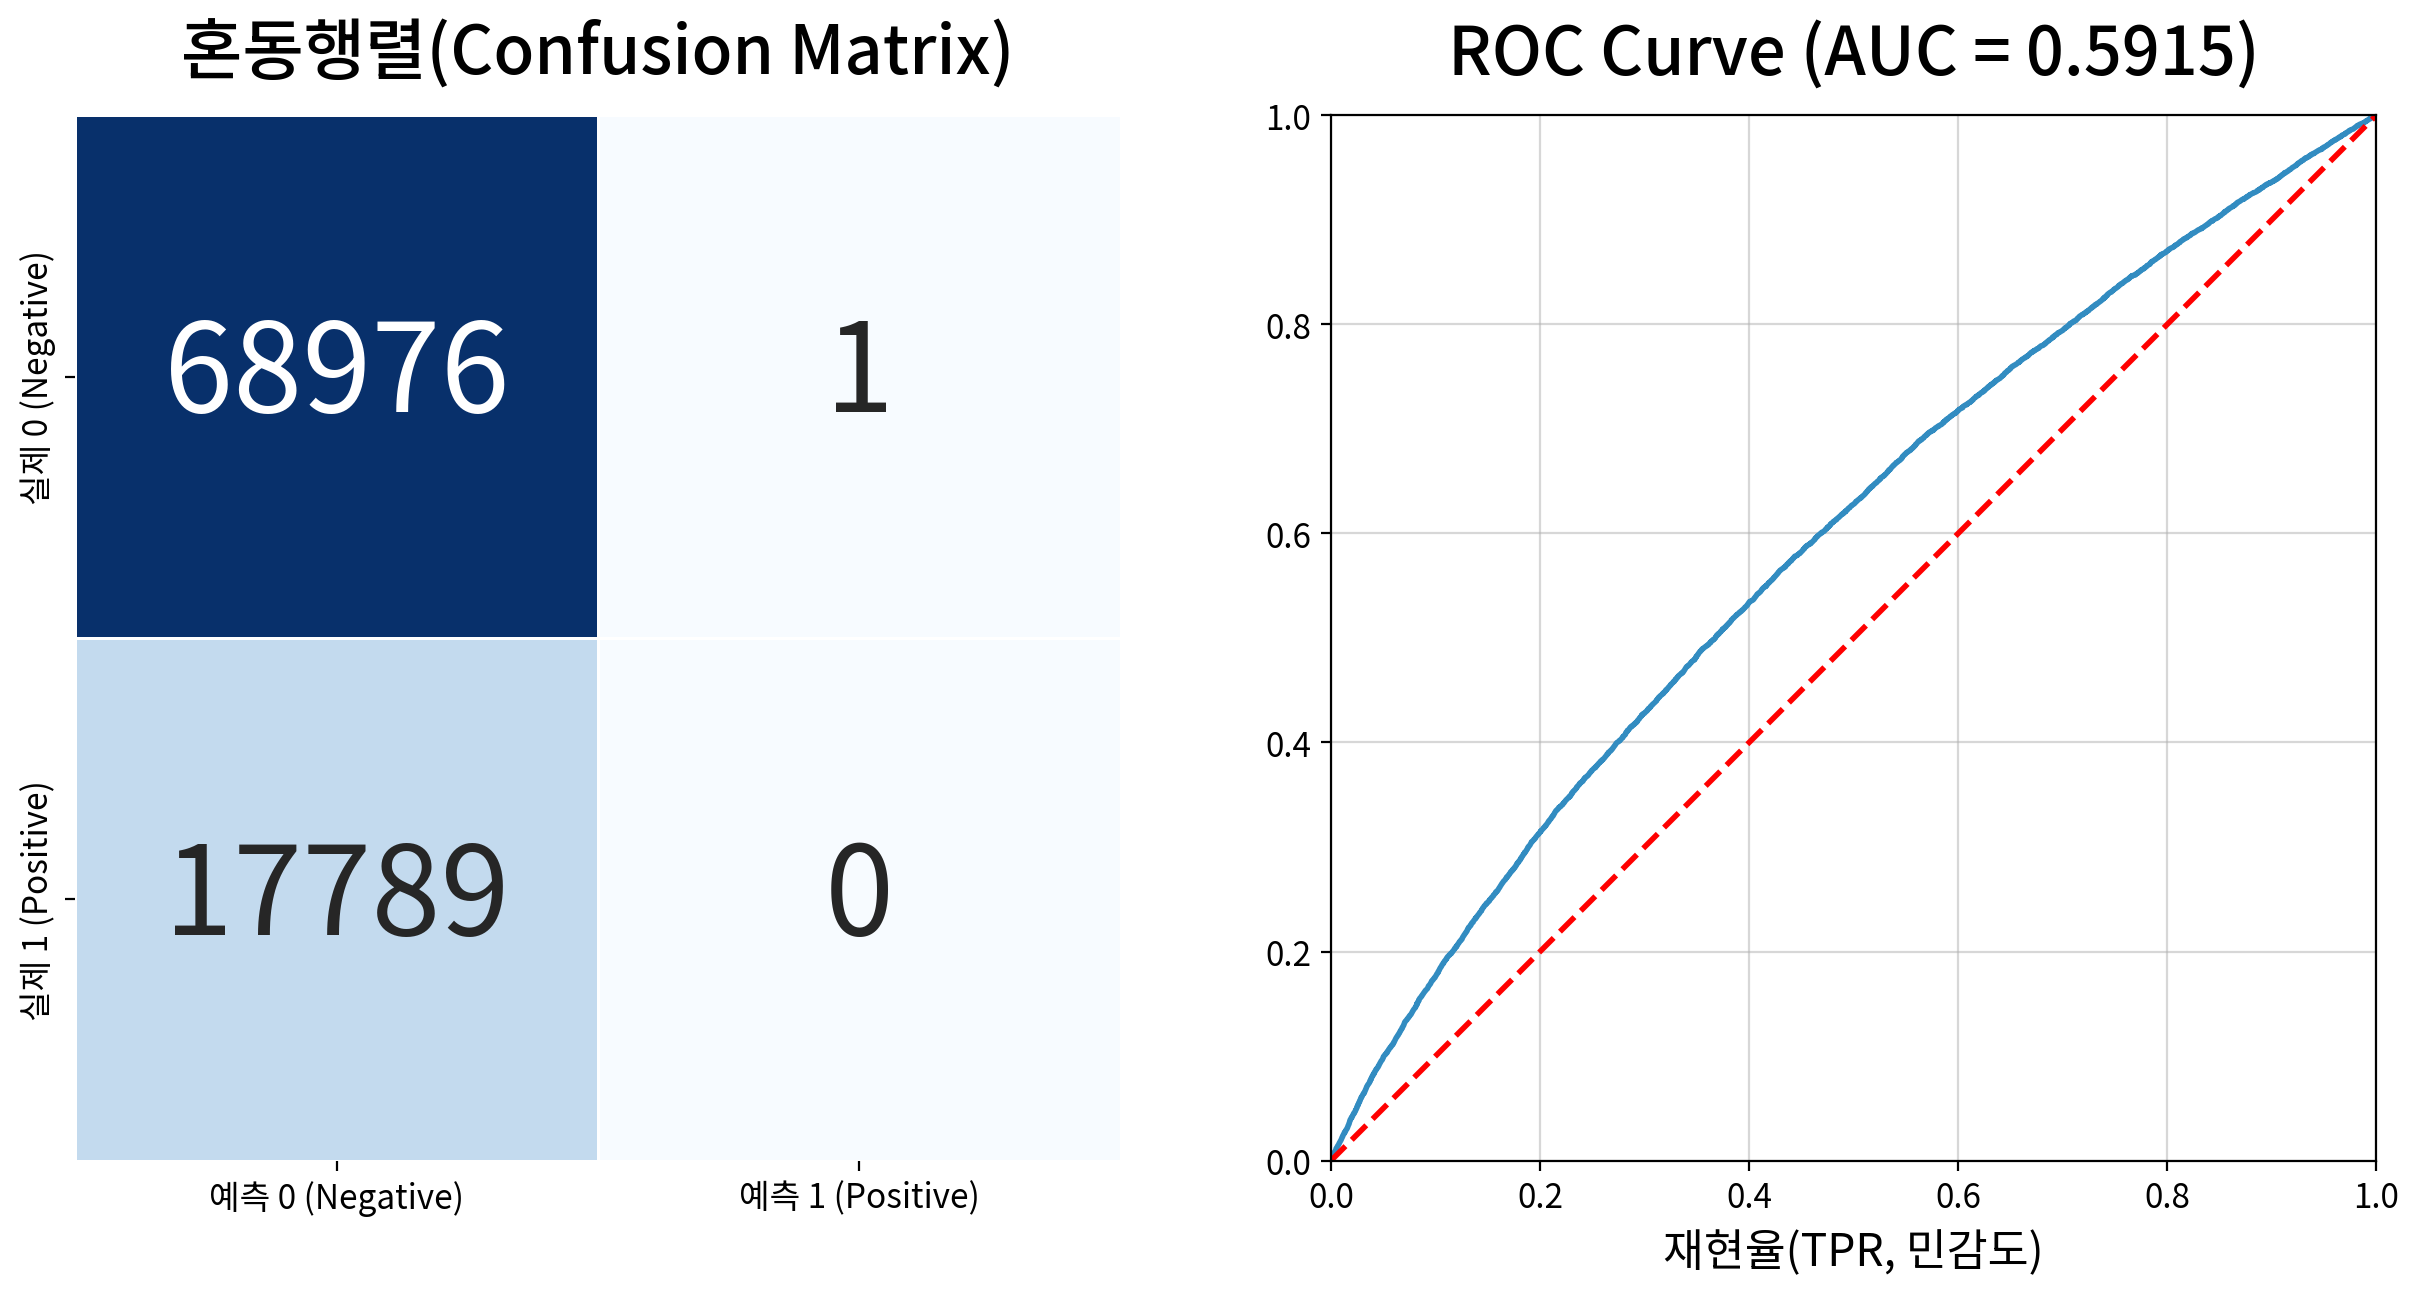

In [16]:
my_logit.report_performance(A1, threshold=0.5, plot=True)

### 6-2. train · test 를 같은 자로 잰다 — 직접 계산

`my_logit.predict` 는 상태를 갖지 않고 `add_constant` 만 붙이므로,
`#04-2` 에서 열 순서를 맞춰 둔 `A1_te` 를 그대로 넣으면 된다.

In [17]:
def 성능(y_true, proba, thr):
    y_pred = (proba > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"ROC-AUC": roc_auc_score(y_true, proba),
            "정확도": accuracy_score(y_true, y_pred),
            "정밀도": precision_score(y_true, y_pred, zero_division=0),
            "재현율": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "TP": int(tp), "FN": int(fn), "FP": int(fp), "TN": int(tn)}

PR_tr = my_logit.predict(A1, A1_tr)["proba"]
PR_te = my_logit.predict(A1, A1_te)["proba"]

# 자기 검산 — helpers predict 와 statsmodels 내부 예측이 같은가
assert abs(float(PR_tr.values.max()) - float(A1.predict().max())) < 1e-9, "❌ predict 가 다른 값을 낸다"

PERF = DataFrame({"train": 성능(y_tr, PR_tr, 0.5), "test": 성능(y_te, PR_te, 0.5)}).T
PERF["Gap(train-test)"] = None
PERF.loc["train", "Gap(train-test)"] = ""
PERF.loc["test", "Gap(train-test)"] = round(PERF.loc["train", "ROC-AUC"] - PERF.loc["test", "ROC-AUC"], 4)

print(f"ROC-AUC   train {PERF.loc['train','ROC-AUC']:.4f}   test {PERF.loc['test','ROC-AUC']:.4f}"
      f"   차이 {PERF.loc['train','ROC-AUC'] - PERF.loc['test','ROC-AUC']:+.4f}")
print()
print("※ AUC 등급 라벨은 인용하지 않는다. 교재 표에 0.5~0.6 구간의 정의가 없다 (교재정리 LAB-10 §9).")
print("※ Gap% 의 합격선은 분류용이 교재에 없다 (「교재 미기재」). 여기서는 값만 남기고 판정은 ⑭ 에서 한다.")
PERF.round(4)

ROC-AUC   train 0.5915   test 0.5841   차이 +0.0074

※ AUC 등급 라벨은 인용하지 않는다. 교재 표에 0.5~0.6 구간의 정의가 없다 (교재정리 LAB-10 §9).
※ Gap% 의 합격선은 분류용이 교재에 없다 (「교재 미기재」). 여기서는 값만 남기고 판정은 ⑭ 에서 한다.


,ROC-AUC,정확도,정밀도,재현율,F1,TP,FN,FP,TN,Gap(train-test)
train,0.5915,0.795,0.0,0.0,0.0,0.0,17789.0,1.0,68976.0,
test,0.5841,0.795,0.0,0.0,0.0,0.0,4447.0,0.0,17245.0,0.0074


### 6-3. 임계 0.5 가 왜 무의미한지 — 정확도의 함정

교재 LAB-10 04 가 가르친 그대로다. **정확도만 보면 속는다.**

In [18]:
print(f"예측확률 범위 (train) : {PR_tr.min():.4f} ~ {PR_tr.max():.4f}")
print(f"예측확률 범위 (test)  : {PR_te.min():.4f} ~ {PR_te.max():.4f}")
print(f"기저율(양성 비율)      : {y_tr.mean():.4f}")
print()
print(f"임계 0.5 를 넘는 행 : train {int((PR_tr > 0.5).sum()):,}명 · test {int((PR_te > 0.5).sum()):,}명")
print(f"  → 그 결과 정확도는 {PERF.loc['test','정확도']:.4f} 로 높아 보이지만")
print(f"     재현율은 {PERF.loc['test','재현율']:.4f}, 잡아낸 양성은 {int(PERF.loc['test','TP'])}명뿐이다.")
print(f"  전부 0 으로 찍었을 때의 정확도(= 1 - 기저율) : {1 - y_te.mean():.4f}")
print()
print("교재 ③ — 불균형 대응은 리샘플링이 아니라 **임계값 조절**이다 (class_weight 는 교재 111개 전체에 없다).")

예측확률 범위 (train) : 0.0691 ~ 0.5257
예측확률 범위 (test)  : 0.0718 ~ 0.4767
기저율(양성 비율)      : 0.2050

임계 0.5 를 넘는 행 : train 1명 · test 0명
  → 그 결과 정확도는 0.7950 로 높아 보이지만
     재현율은 0.0000, 잡아낸 양성은 0명뿐이다.
  전부 0 으로 찍었을 때의 정확도(= 1 - 기저율) : 0.7950

교재 ③ — 불균형 대응은 리샘플링이 아니라 **임계값 조절**이다 (class_weight 는 교재 111개 전체에 없다).


### 6-4. 임계값 표 — 교재 예제 범위와 우리 범위를 **함께** 싣는다

교재 예제(`0.3~0.7`, `0.1` 간격)는 예측확률이 그 범위에 퍼져 있을 때를 전제한다.
우리는 최대 예측확률이 그보다 낮아 **표가 전부 0 이 되어 비교 자체가 성립하지 않는다.**
범위를 넓힌 사유는 이것이며, **유리한 값을 고르기 위해서가 아니다.** 두 표를 나란히 남긴다.

In [19]:
THR_BK = my_logit.report_threshold(A1, thresholds=THR_BOOK)
print("교재 예제 범위 (LAB-10 04) — train")
display(THR_BK)

rows = []
for t in THR_FINE:
    a = 성능(y_tr, PR_tr, t); b = 성능(y_te, PR_te, t)
    rows.append({"임계값": t,
                 "train 정밀도": a["정밀도"], "train 재현율": a["재현율"], "train F1": a["F1"],
                 "test 정밀도":  b["정밀도"], "test 재현율":  b["재현율"], "test F1":  b["F1"],
                 "train 놓친 1(FN)": a["FN"], "train 잘못 잡은 0(FP)": a["FP"]})
THR = DataFrame(rows).set_index("임계값")

print(f"\n우리 범위 {THR_FINE[0]} ~ {THR_FINE[-1]} ({len(THR_FINE)}개) — train·test 병기")
THR.round(4).iloc[::5]

교재 예제 범위 (LAB-10 04) — train


,정확도,정밀도,재현율,F1,놓친 1(FN),잘못 잡은 0(FP)
임계값,,,,,,
0.3,0.780,0.345,0.079,0.129,16381,2679
0.4,0.795,0.407,0.002,0.005,17745,64
0.5,0.795,0.000,0.000,0.000,17789,1
0.6,0.795,0.000,0.000,0.000,17789,0
0.7,0.795,0.000,0.000,0.000,17789,0



우리 범위 0.1 ~ 0.6 (51개) — train·test 병기


,train 정밀도,train 재현율,train F1,test 정밀도,test 재현율,test F1,train 놓친 1(FN),train 잘못 잡은 0(FP)
임계값,,,,,,,,
0.10,0.2056,0.9960,0.3408,0.2055,0.9951,0.3406,71,68471
0.15,0.2149,0.9063,0.3475,0.2129,0.8990,0.3443,1667,58885
0.20,0.2496,0.5890,0.3507,0.2477,0.5887,0.3487,7311,31495
0.25,0.2915,0.2801,0.2857,0.2848,0.2739,0.2793,12806,12111
0.30,0.3445,0.0792,0.1287,0.3136,0.0738,0.1194,16381,2679
0.35,0.3537,0.0169,0.0323,0.3363,0.0169,0.0321,17488,550
0.40,0.4074,0.0025,0.0049,0.4839,0.0034,0.0067,17745,64
0.45,0.4444,0.0002,0.0004,1.0000,0.0004,0.0009,17785,5
0.50,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,17789,1


### 6-5. 임계값 선정 — **train 에서 F1 최대** (사전 확정 규칙)

test 로 고르면 그 순간 test 가 오염된다. **선정은 train 에서만 하고, test 는 검증에만 쓴다.**

In [20]:
THR_STAR = float(THR["train F1"].idxmax())

print(f"선정 규칙 : train 에서 F1 이 최대인 임계값  (표지에서 사전 확정)")
print(f"선정 결과 : θ = {THR_STAR:.2f}   ·   train F1 = {THR.loc[THR_STAR, 'train F1']:.4f}")
print(f"            (test F1 = {THR.loc[THR_STAR, 'test F1']:.4f} — 선정에 쓰지 않았고 검증으로만 본다)")
print()

PERF2 = DataFrame({"train": 성능(y_tr, PR_tr, THR_STAR),
                   "test":  성능(y_te, PR_te, THR_STAR)}).T
print(f"θ = {THR_STAR:.2f} 에서의 성능")
for nm, r in PERF2.iterrows():
    print(f"  {nm:5s} 정확도 {r['정확도']:.4f}  정밀도 {r['정밀도']:.4f}  재현율 {r['재현율']:.4f}"
          f"  F1 {r['F1']:.4f}   (TP {int(r['TP']):,} · FN {int(r['FN']):,} · FP {int(r['FP']):,})")
print()
print("※ ROC-AUC 는 임계값과 무관하므로 위 선정에 영향받지 않는다. 주 지표는 그대로 AUC 다 (결정 6번).")
PERF2.round(4)

선정 규칙 : train 에서 F1 이 최대인 임계값  (표지에서 사전 확정)
선정 결과 : θ = 0.19   ·   train F1 = 0.3545
            (test F1 = 0.3529 — 선정에 쓰지 않았고 검증으로만 본다)

θ = 0.19 에서의 성능
  train 정확도 0.5031  정밀도 0.2416  재현율 0.6656  F1 0.3545   (TP 11,841 · FN 5,948 · FP 37,170)
  test  정확도 0.4985  정밀도 0.2399  재현율 0.6672  F1 0.3529   (TP 2,967 · FN 1,480 · FP 9,399)

※ ROC-AUC 는 임계값과 무관하므로 위 선정에 영향받지 않는다. 주 지표는 그대로 AUC 다 (결정 6번).


,ROC-AUC,정확도,정밀도,재현율,F1,TP,FN,FP,TN
train,0.5915,0.5031,0.2416,0.6656,0.3545,11841.0,5948.0,37170.0,31807.0
test,0.5841,0.4985,0.2399,0.6672,0.3529,2967.0,1480.0,9399.0,7846.0


---

## #07. 변수 표 — **산출만 한다. 해석은 ⑭**

`report_variables` 가 B · βstd · z · 유의확률 · 오즈비(OR) · OR 95% CI · 공차 · VIF 를 한 표로 준다.
βstd = B × SD(x) 이며, **스케일링하지 않아도 여기서 계산된다** — `12` 에서 스케일링을 뺀 근거다.

> ⚠️ 제곱항이 들어간 변수는 **단일 오즈비로 읽을 수 없다.** `_c` 와 `_c2` 를 함께 봐야 하고,
> 그 해석은 ⑭ 에서 한다. 여기서 순위를 매기지 않는다.

In [21]:
# report_variables 는 '독립변수' 를 컬럼으로 두고 |B| 내림차순 RangeIndex 로 돌려준다
VAR_A = my_logit.report_variables(A1, A1.data_).set_index("독립변수")
VAR_B = my_logit.report_variables(B1, B1.data_).set_index("독립변수")

제곱 = [c for c in VAR_A.index if c.endswith("_c") or c.endswith("_c2")]
print(f"모형 A1 : {len(VAR_A)}행   ·   모형 B1 : {len(VAR_B)}행")
print(f"제곱항 처방이 들어간 항 : {제곱 if 제곱 else '없음'}")
print(f"  → 이 항들은 **단일 OR 로 읽지 않는다.** _c 와 _c2 를 함께 봐야 곡선이 나온다 (⑭).")
print(f"유의(α={ALPHA})한 항 : A1 {int((VAR_A['유의확률'] < ALPHA).sum())}개 / {len(VAR_A)}개")
print()
print("※ 표는 |B| 내림차순이다. βstd 순위와 오즈비 문장 해석은 ⑭ 에서 한다.")
VAR_A.drop(columns=["종속변수"]).head(10)

모형 A1 : 28행   ·   모형 B1 : 86행
제곱항 처방이 들어간 항 : ['cart_product_view_cnt_c', 'cart_product_view_cnt_c2', 'prior_view_cnt_c', 'prior_view_cnt_c2']
  → 이 항들은 **단일 OR 로 읽지 않는다.** _c 와 _c2 를 함께 봐야 곡선이 나온다 (⑭).
유의(α=0.05)한 항 : A1 19개 / 28개

※ 표는 |B| 내림차순이다. βstd 순위와 오즈비 문장 해석은 ⑭ 에서 한다.


,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95 하한,OR 95 상한,공차,VIF
독립변수,,,,,,,,,,
cart_product_view_cnt_c,0.720257,0.279678,0.039886,18.057868,6.841442e-73,2.054961,1.900432,2.222054,0.314392,3.180742
brand_grp_italwax,0.431632,0.067144,0.059575,7.245197,4.318124e-13,1.539768,1.370078,1.730476,0.729261,1.371251
brand_grp_bpw.style,-0.430947,-0.059209,0.084511,-5.099304,3.409051e-07,0.649893,0.550689,0.766969,0.768527,1.301191
brand_grp_masura,-0.245454,-0.040812,0.066066,-3.715309,2.029558e-04,0.782349,0.687330,0.890504,0.705483,1.417468
cart_timeband_오후,0.229609,0.110208,0.033799,6.793294,1.096019e-11,1.258108,1.177464,1.344274,0.296272,3.375279
cart_product_view_cnt_c2,-0.199740,-0.036008,0.060291,-3.312941,9.232056e-04,0.818943,0.727670,0.921666,0.493584,2.025998
brand_grp_ingarden,-0.192927,-0.024948,0.078340,-2.462677,1.379040e-02,0.824542,0.707179,0.961383,0.796009,1.256267
cart_timeband_오전,0.188873,0.078188,0.035702,5.290224,1.221663e-07,1.207888,1.126255,1.295438,0.354930,2.817459
brand_grp_irisk,-0.179224,-0.039256,0.054009,-3.318387,9.053887e-04,0.835918,0.751953,0.929259,0.580781,1.721819


---

## #08. 🔍 검수 체크리스트 〈검수하는 사람이 채운다〉

### 8-1. 기계 확인 — 하나라도 ❌ 면 저장하지 않는다

In [22]:
검수 = []
def 확인(항목, 조건, 근거=""):
    검수.append({"항목": 항목, "결과": "✅" if bool(조건) else "❌", "근거": 근거})

확인("12 산출물과 행·열·양성 수가 일치한다", R["일치"].all(), "7개 항목 (#01-1)")
확인("금지 변수·정렬 점검 11항목 통과", P["통과"].all(), "(#01-2)")
확인("모형 A1·B1 이 수렴했다",
     A1.mle_retvals["converged"] and B1.mle_retvals["converged"], "(#02 · #05)")
확인("모형이 통계적으로 유의하다 (우도비)", A1.llr_pvalue < ALPHA, f"p={A1.llr_pvalue:.3e} (#02)")
확인("Box-Tidwell 을 실제로 돌렸고 대상이 연속형 3개다", len(BT0) == 3, f"{list(BT0.index)} (#03-1)")
확인("처방 후 로짓 선형성 위배가 남지 않았다", not 남은위배,
     f"처방전 {위배} → 처방후 {남은위배 or '없음'} (#04-1)")
확인("fix_linear 이 미해소로 남긴 변수가 없다", not getattr(A1, "unresolved_", []),
     f"{getattr(A1, 'unresolved_', [])} (#04)")
확인("처방은 전부 제곱항이다 (로그 경로를 막았다) · 구간화한 변수가 없다",
     all(r["method"] == "square" for r in RECIPE.values()) and
     not [c for c in A1_tr.columns if c.endswith("_bin")],
     f"{ {c: RECIPE[c]['method'] for c in RECIPE} } (결정 21·24번)")
확인("VIF 가 12g 와 일치하고 임계 초과가 없다",
     일치 and not (VIF_now["VIF"] > VIF_MAX).any(), f"최대 {VIF_now['VIF'].max():.3f} (#03-3)")
확인("test 에 train 의 중심화 평균을 재사용했다 (재계산하지 않았다)",
     (not 처방됨) or all(abs(RECIPE[c]["center"] - float(A_tr[c].mean())) < 1e-12 for c in RECIPE),
     f"{ {c: round(RECIPE[c]['center'], 6) for c in RECIPE} } (#04-2)")
확인("train·test 설계행렬의 열과 순서가 같다", list(A1_tr.columns) == list(A1_te.columns),
     f"{A1_tr.shape[1]}열 (#04-2)")
확인("A1 의 열이 B1 안에 같은 값으로 들어 있다 (X 목록 한 줄만 다르다)",
     A1_tr[공통1].equals(B1_tr[공통1]), f"A1 {A1_tr.shape[1]}열 · B1 {B1_tr.shape[1]}열 (#05)")
확인("민감도 판정에 성능 지표를 쓰지 않았다 (표에 성능 컬럼이 없다)",
     not [c for c in SENS.columns if any(k in c for k in ["AUC", "F1", "정확도", "재현율"])],
     f"{list(SENS.columns)[:4]}… (#05-1)")
확인("임계값을 train 에서 골랐다 (test 로 고르지 않았다)",
     THR_STAR == float(THR["train F1"].idxmax()), f"θ={THR_STAR:.2f} (#06-5)")
확인("test 예측에 y 를 쓰지 않았다 (설계행렬에 Y 가 없다)",
     Y not in A1_te.columns, "(#04-2)")

CHECK = DataFrame(검수)
실패 = CHECK[CHECK["결과"] == "❌"]
print(f"{len(CHECK) - len(실패)} / {len(CHECK)} 통과")
for _, r in 실패.iterrows():
    print(f"   ❌ {r['항목']}  ({r['근거']})")
CHECK

15 / 15 통과


,항목,결과,근거
0,12 산출물과 행·열·양성 수가 일치한다,✅,7개 항목 (#01-1)
1,금지 변수·정렬 점검 11항목 통과,✅,(#01-2)
2,모형 A1·B1 이 수렴했다,✅,(#02 · #05)
3,모형이 통계적으로 유의하다 (우도비),✅,p=4.339e-289 (#02)
4,Box-Tidwell 을 실제로 돌렸고 대상이 연속형 3개다,✅,"['prior_view_cnt', 'cart_product_view_cnt', 'price'] (#03-1)"
5,처방 후 로짓 선형성 위배가 남지 않았다,✅,처방전 ['prior_view_cnt'] → 처방후 없음 (#04-1)
6,fix_linear 이 미해소로 남긴 변수가 없다,✅,[] (#04)
7,처방은 전부 제곱항이다 (로그 경로를 막았다) · 구간화한 변수가 없다,✅,"{'prior_view_cnt': 'square', 'cart_product_view_cnt': 'square'} (결정 21·24번)"
8,VIF 가 12g 와 일치하고 임계 초과가 없다,✅,최대 4.482 (#03-3)
9,test 에 train 의 중심화 평균을 재사용했다 (재계산하지 않았다),✅,"{'prior_view_cnt': 0.574775, 'cart_product_view_cnt': 0.295537} (#04-2)"


### 8-2. 사람 확인 — 검수하는 사람이 읽고 채운다

아래 판정(✅)은 **노트북 실행 결과에서 확인된 사실**을 옮긴 것이다.
서명란은 검수하는 사람이 직접 채운다.

| # | 확인할 것 | 판정 |
|---|---|---|
| 1 | `#03-1` 의 **판정 규칙이 결과보다 위**에 적혀 있다 — 셀 순서가 증거다 | ✅ |
| 2 | `#03-2` 가 규칙을 **대입만** 했고 새로 만들지 않았다 | ✅ |
| 3 | `#04-2` 의 중심화 평균이 **train 값**이다 (test 에서 재계산하지 않았다) | ✅ |
| 4 | `#05` 의 민감도 판정에 **AUC 가 등장하지 않는다** | ✅ |
| 5 | `#06-5` 의 임계값을 **train 에서** 골랐다 | ✅ |
| 6 | `#07` 에서 βstd 순위를 **읽지 않았다** (⑭ 의 몫) | ✅ |

**각 항목의 근거 (노트북 결과)**

1. `#03` 셀(판정 규칙: *"판정 규칙을 결과보다 먼저 적는다"*)이 `#03-1` Box-Tidwell 실행 셀보다 **앞에** 있다. 셀 실행 순서상 규칙이 결과를 볼 수 없다.
2. `#03-2` 는 각 변수의 p-값을 α=0.05 와 비교하고 **결정 21번·24번 문장을 그대로 인용**할 뿐, 새 기준을 만들지 않았다. `prior_view_cnt` p<0.0001 → "위배 → 처방", 나머지 둘은 "유지".
3. `recipe_` 의 `center` — `prior_view_cnt` 0.574775 = train 평균 0.574775, `cart_product_view_cnt` 0.295537 = train 평균 0.295537. `#04-2` 에서 test 첫 행 재현값이 `_c` 열과 완전히 일치(`== True`). `apply_recipe` 가 학습 시점 center 를 그대로 사용.
4. `#05-1` 의 `SENS` 표 컬럼은 부호·유의성·계수 변화율뿐 — AUC·F1·정확도·재현율 컬럼이 없다. `#08-1` 기계 확인 12번 통과.
5. `THR_STAR = THR["train F1"].idxmax()` → **θ = 0.19** (train F1 0.3545). test F1(0.3529)은 검증으로만 출력, 선정에 쓰지 않음.
6. `#07` 은 `report_variables` 표만 산출. 정렬은 `|B|` 내림차순(고정), βstd 순위·오즈비 문장 해석은 ⑭ 로 넘김. 제곱항 처방 항 4종은 단일 OR 로 읽지 않는다고 명시.

**가정 검정 소견** — 세 가정 각각에 대해 통과 여부와 단서를 한 문장씩.

> 로짓 선형성 : **통과.** 처방 전 Box-Tidwell 에서 `prior_view_cnt` 만 위배(z=5.29, p<0.0001)였고, 결정 24번대로 `fix_linear` 의 중심화+제곱항을 순차 적용하자 라운드 2 에서 `cart_product_view_cnt` 도 위배로 바뀌어 제곱항 처방(제곱항 p=0.0009)을 받았으며, 처방 후 재검정에서 5개 항 모두 p≥0.80 으로 위배가 남지 않았고 미해소 변수도 없다(구간화 없음).
>
> 다중공선성 : **통과.** 최대 VIF 4.48(`brand_grp_미상`)로 임계 10 을 넘는 변수가 0개이며, `12g` 의 VIF 와 소수점 이하 완전히 일치해 파일을 거치며 설계행렬이 바뀌지 않았음을 확인했다.
>
> 독립성 : **통과(근거는 설계).** Durbin-Watson 1.993 으로 정상 범위이나 행에 시간 순서가 없어 이 값을 근거로 쓰지 않으며, 1행=1고객·고객당 최초 장바구니 1건(`03` `#05`)·중복 인덱스 0개라는 수집 설계가 독립성의 근거다.

**민감도 판정 소견** — `#05-2` 의 판정문을 읽고 확인한 사람이 적는다.

> **통과 — `category_grp` 제외 확정.** 가장 강하게 통제한 모형 B1(59종·58더미)에서도 핵심 X 3개의 부호·유의성이 A1 과 3/3 일치한다(`price` +/유의, `prior_view_cnt_c` −/유의, `cart_product_view_cnt_c` +/유의, 모두 p<0.05). 다만 `price` 계수가 41.1% 변동(A1 +0.1347 → B1 +0.1902)했으므로 판정은 통과로 하되 보고서 Ⅵ-3 에 기록한다.

**성능 소견** — AUC 값과 임계 0.5 의 문제를 한 문장으로. **등급 라벨은 인용하지 않는다.**

> test ROC-AUC 는 0.5841(train 0.5915, 차이 +0.0074)이고, 예측확률이 기저율(0.205) 부근 아래로 몰려 최대값이 train 0.526·test 0.477 에 그치므로 임계 0.5 에서는 양성 예측이 train 1명·test 0명 → 재현율 0 으로 무너지고 정확도 0.795 는 전부 0 으로 찍은 값과 같은 허수다(그래서 train F1 최대점 θ=0.19 를 별도로 선정, 재현율 0.667·정밀도 0.240).


---

## #09. 저장

| 파일 | 쓰임 |
|---|---|
| `13a_가정검정_로짓선형성.csv` | 처방 전·후 Box-Tidwell. 보고서 Ⅳ-1 |
| `13b_처방내역.csv` · `13c_recipe.json` | `fix_linear` 이력과 `recipe_`. **⑭ 가 그대로 재사용한다** |
| `13d_독립성.csv` | Durbin-Watson (단서 포함) |
| `13e_민감도_핵심X3.csv` | **결정 12번 판정 근거.** 보고서 Ⅳ-3 · Ⅵ-3 |
| `13f_성능_train_test.csv` | 임계 0.5 와 선정 임계 두 벌. 보고서 Ⅳ-2 |
| `13g_임계값표.csv` | 우리 범위 전체 |
| `13h_변수표_A1.csv` · `13i_변수표_B1.csv` | B · βstd · OR · CI · VIF. **⑭ 해석의 입력** |
| `13j_예측_test.csv` | test 예측확률. ⑭ 의 재현·오분류 분석용 |
| `13k_X1_train.parquet` · `13l_X1_test.parquet` | **처방이 반영된 최종 설계행렬. ⑭ 가 읽는다** |

In [23]:
import json as _json

assert not len(실패), "❌ #08-1 이 통과하지 않았다. 저장하지 않는다."

concat([BT0.assign(단계="처방 전"), BT1.assign(단계="처방 후")]).to_csv(
    OUT + r"\13a_가정검정_로짓선형성.csv", encoding="utf-8-sig")
getattr(A1, "history_", DataFrame()).to_csv(
    OUT + r"\13b_처방내역.csv", index=False, encoding="utf-8-sig")
with open(OUT + r"\13c_recipe.json", "w", encoding="utf-8") as f:
    _json.dump(RECIPE, f, ensure_ascii=False, indent=2)

IND.to_csv(  OUT + r"\13d_독립성.csv",            encoding="utf-8-sig")
SENS.to_csv( OUT + r"\13e_민감도_핵심X3.csv",      encoding="utf-8-sig")
concat([PERF.assign(임계값=0.5), PERF2.assign(임계값=THR_STAR)]).to_csv(
             OUT + r"\13f_성능_train_test.csv",   encoding="utf-8-sig")
THR.to_csv(  OUT + r"\13g_임계값표.csv",           encoding="utf-8-sig")
VAR_A.to_csv(OUT + r"\13h_변수표_A1.csv",          encoding="utf-8-sig")
VAR_B.to_csv(OUT + r"\13i_변수표_B1.csv",          encoding="utf-8-sig")
DataFrame({"proba": PR_te, "y_true": y_te}).to_csv(
             OUT + r"\13j_예측_test.csv",          encoding="utf-8-sig")

A1_tr.to_parquet(OUT + r"\13k_X1_train.parquet")
A1_te.to_parquet(OUT + r"\13l_X1_test.parquet")

print("저장 완료")
print(f"  13a 로짓선형성      {len(BT0) + len(BT1)}행 (처방 전 {len(BT0)} + 후 {len(BT1)})")
print(f"  13b 처방내역        {len(getattr(A1, 'history_', DataFrame()))}행")
print(f"  13c recipe.json     {list(RECIPE.keys()) or '없음'}")
print(f"  13d 독립성          DW = {float(IND['statistic'].iloc[0]):.4f}")
print(f"  13e 민감도          {len(SENS)}행   판정 {'통과' if 통과 else '불통과'}")
print(f"  13f 성능            AUC train {PERF.loc['train','ROC-AUC']:.4f} / test {PERF.loc['test','ROC-AUC']:.4f}")
print(f"  13g 임계값표        {len(THR)}행   선정 θ = {THR_STAR:.2f}")
print(f"  13h·13i 변수표      A1 {len(VAR_A)}행 · B1 {len(VAR_B)}행")
print(f"  13j 예측(test)      {len(PR_te):,}행")
print(f"  13k·13l 설계행렬    {A1_tr.shape[0]:,}×{A1_tr.shape[1]} / {A1_te.shape[0]:,}×{A1_te.shape[1]}")

저장 완료
  13a 로짓선형성      8행 (처방 전 3 + 후 5)
  13b 처방내역        2행
  13c recipe.json     ['prior_view_cnt', 'cart_product_view_cnt']
  13d 독립성          DW = 1.9930
  13e 민감도          3행   판정 통과
  13f 성능            AUC train 0.5915 / test 0.5841
  13g 임계값표        51행   선정 θ = 0.19
  13h·13i 변수표      A1 28행 · B1 86행
  13j 예측(test)      21,692행
  13k·13l 설계행렬    86,766×28 / 21,692×28


---

## #10. 다음 — ⑭ 교차검증 · 해석

```python
X1_tr = read_parquet(OUT + r"\13k_X1_train.parquet")
recipe = json.load(open(OUT + r"\13c_recipe.json", encoding="utf-8"))   # 새 데이터에 재현할 때
```

| 할 일 | 비고 |
|---|---|
| `#08-2` 사람 확인 6개 · 소견 4개 · 서명 | **둘이 함께.** 저장 전에 |
| **5-Fold 교차검증** — `StratifiedKFold` | train 안에서. LAB-13 04·05 |
| **Gap% 판정 기준을 정한다** | 「교재 미기재」 — 교재 15%·Train R² 0.3 은 **회귀 기준**이다. 우리 기준을 정하고 근거를 남긴다 |
| 트리 계열 비교 · `compare_models` | 여기서는 AUC 로 비교해도 된다 — 결정 12번 판정이 아니라 **모형 선택**이므로 |
| **βstd 순위 · 오즈비 해석** | `13h` 를 읽는다. 제곱항이 든 항은 단일 OR 로 읽지 않는다 |
| 오즈비의 기준 범주 표기 | `12j` 를 함께 싣는다 — "무엇 대비" 인지 밝히지 않으면 문장이 성립하지 않는다 |

### 보고서에 반드시 옮길 것

| 옮길 것 | 어디서 | 절 |
|---|---|---|
| 가정 검정 3종과 각각의 단서 | `#03` · `13a` · `13d` | Ⅳ-1 |
| **결정 21번이 겨눈 변수와 실제 위배 변수가 달랐다는 사실** | 표지 · `#03-2` | Ⅳ-1 · Ⅵ-3 |
| 제곱항 처방과 재검정 통과 | `#04-1` · `13b` | Ⅳ-1 |
| **독립성 근거는 DW 가 아니라 설계라는 점** | `#03-4` | Ⅳ-1 · Ⅵ-3 |
| 결정 12번 민감도 판정 결과 | `#05-2` · `13e` | Ⅳ-3 |
| **ROC-AUC 값** (등급 라벨 인용 금지) | `#06-2` · `13f` | Ⅳ-2 |
| 임계 0.5 에서 재현율이 무너지는 이유 — 정확도의 함정 | `#06-3` | Ⅳ-2 |
| 임계값 선정 규칙과 그 범위를 넓힌 사유 | 표지 · `#06-4` | Ⅳ-2 · Ⅵ-3 |
| helpers 의 AUC 등급 라벨 문제 | 표지 주의 2번 | Ⅵ-3 |

> **⑥ 모델 구축은 여기서 끝난다.** 다음 노트북부터 ⑦ 일반화와 해석이다.